Name: Kriti Bhattacharya
Github: Kritiin5
USC ID: 3277100685

1b. (i)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_path = '../data/CCPP/Folds5x2_pp.xlsx'
data = pd.read_excel(data_path, sheet_name = 0)
#data.head()

In [53]:
rows, columns = data.shape
print('Number of rows: ', rows)
print('Number of columns: ', columns)

data.info()
print(data.columns)

Number of rows:  9568
Number of columns:  5
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')


The dataset contains 9,568 rows and 5 columns. Each row represents one
hourly observation of the power plant. The columns AT, V, AP, and RH are
the predictor variables representing ambient temperature, exhaust
vacuum, ambient pressure, and relative humidity. PE is the response
variable representing net hourly electrical energy output.

1b. (ii)

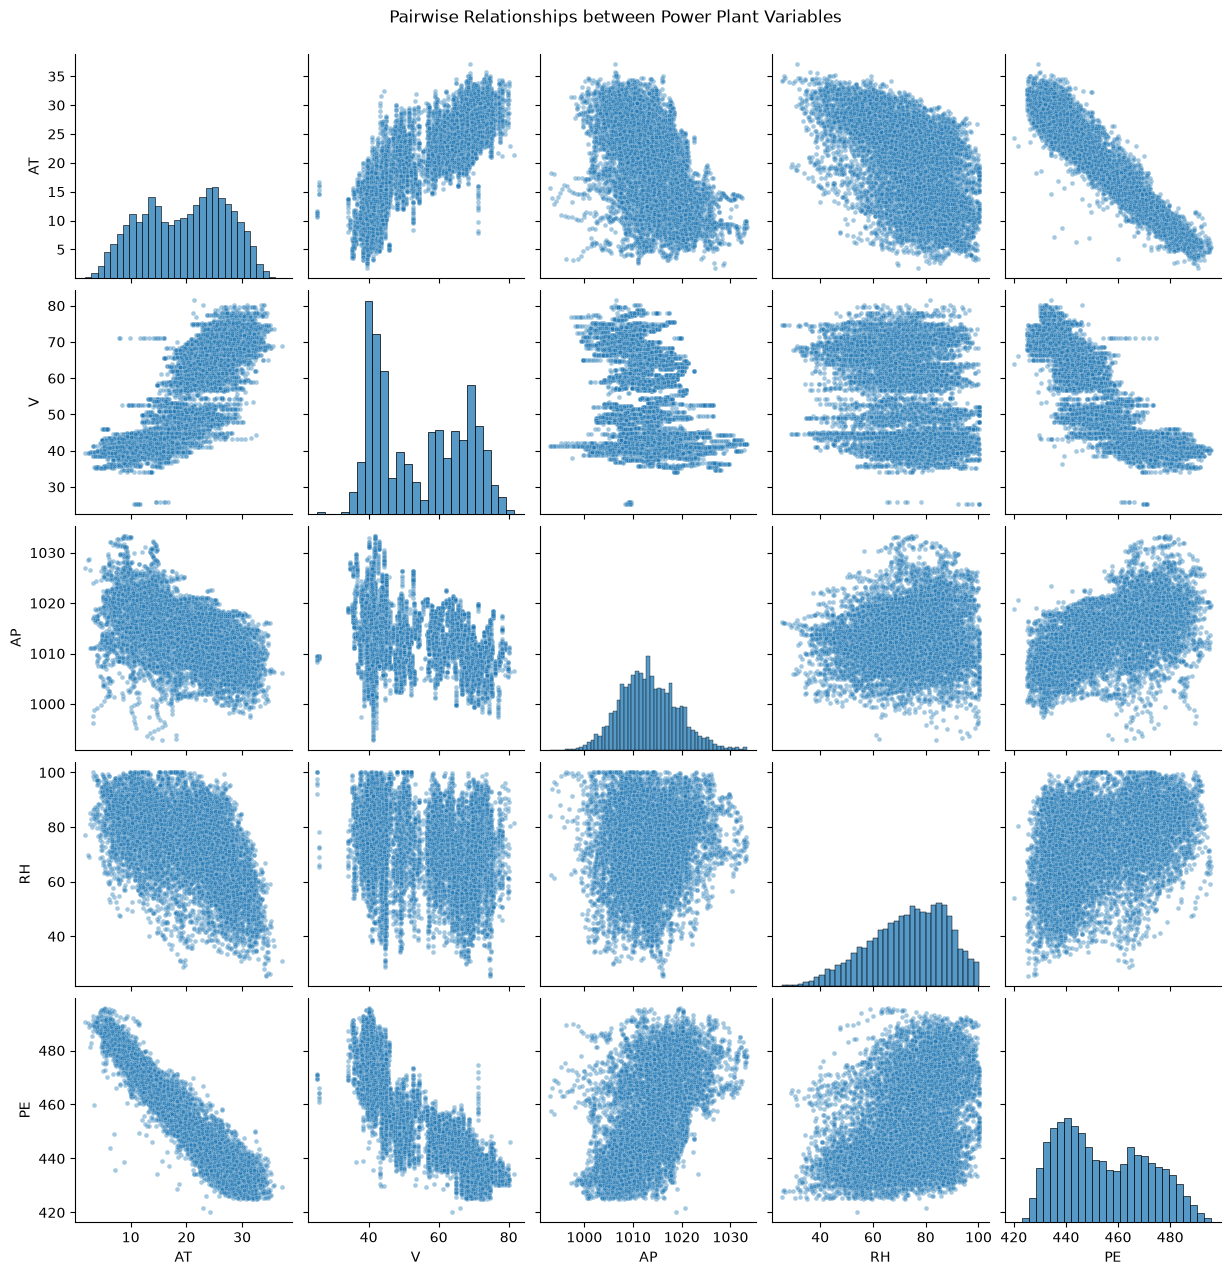

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [54]:
pair_plot = sns.pairplot(data, diag_kind = 'hist', plot_kws = {'alpha': 0.4, 's': 12})
pair_plot.fig.suptitle('Pairwise Relationships between Power Plant Variables', y=1.02)
plt.show()

correlation_matrix = data.corr()
correlation_matrix.round(3)

AT and V have strong negative relationships with PE, while AP has a moderate positive relationship and RH has a weaker positive relationship with PE. Among the predictors, AT and V are strongly positively related, while AT is negatively related to AP and RH. The plots suggest that using multiple predictors may improve the prediction of PE.

1b. (iii)

In [55]:
summary_statistics = pd.DataFrame({
    'Mean': data.mean(),
    'Median': data.median(),
    'Minimum': data.min(),
    'Maximum': data.max(),
    'Range': data.max() - data.min(),
    'First Quartile (Q1)': data.quantile(0.25),
    'Third Quartile (Q3)': data.quantile(0.75),
    'IQR': data.quantile(0.75) - data.quantile(0.25)
})

summary_statistics.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


1c.

In [56]:
import statsmodels.api as sm

predictors = ['AT', 'V', 'AP', 'RH']
response = data['PE']

simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]])
    model = sm.OLS(response, X).fit()
    
    simple_models[predictor] = model
    
    simple_results.append({
        'Predictor': predictor,
        'Intercept': model.params['const'],
        'Coefficient': model.params[predictor],
        'Standard Error': model.bse[predictor],
        'p-value': model.pvalues[predictor],
        'R-squared': model.rsquared
    })

simple_regression_results = pd.DataFrame(simple_results)
simple_regression_results.round(4)

,Predictor,Intercept,Coefficient,Standard Error,p-value,R-squared
0,AT,497.0341,-2.1713,0.0074,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,0.0,0.1519


Regression models

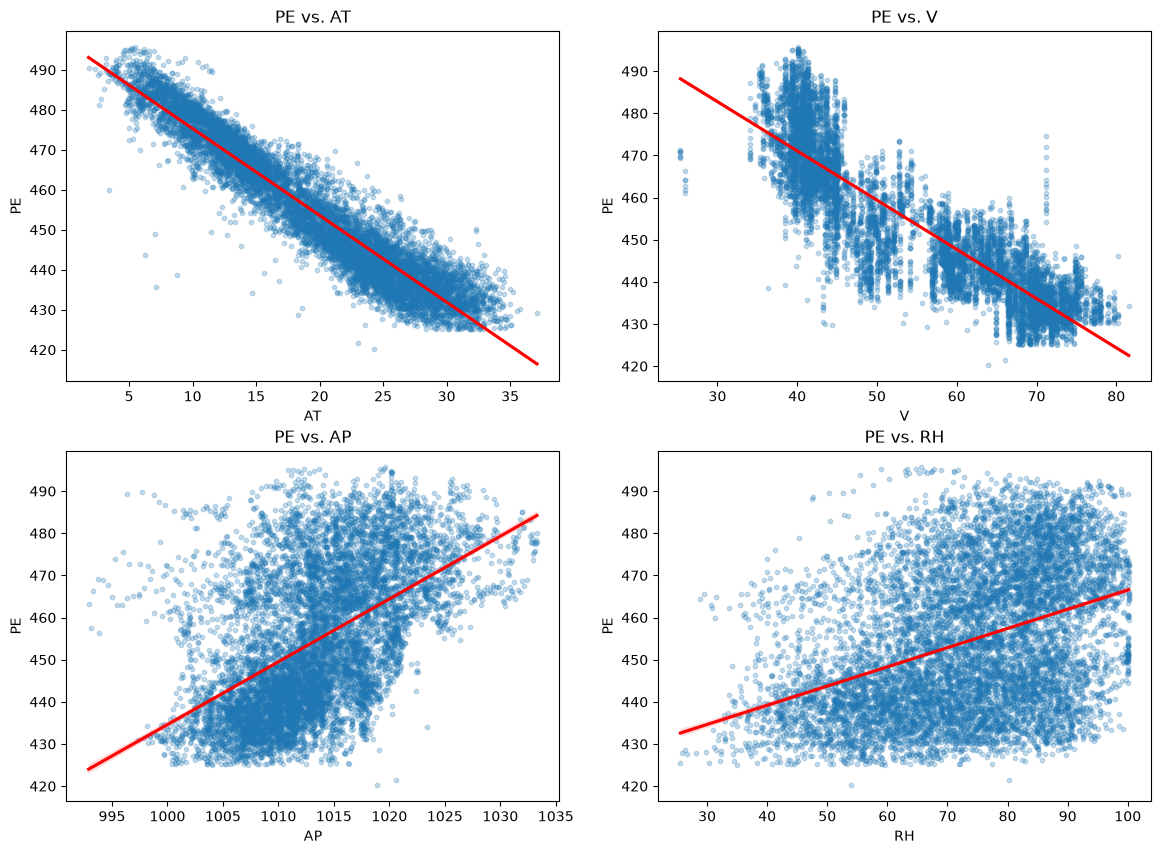

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(data=data, x=predictor, y='PE', scatter_kws={'alpha': 0.25, 's': 10}, line_kws={'color': 'red'}, ax=ax)
    
    ax.set_title(f'PE vs. {predictor}')

plt.show()

Potential outliers

In [58]:
outliers = []

for feature in predictors:
    current_model = simple_models[feature]
    model_info = current_model.get_influence()
    residuals = model_info.resid_studentized_external
    
    number_of_outliers = sum(abs(residuals) > 3)
    
    outliers.append([feature, number_of_outliers])

outlier_table = pd.DataFrame(outliers, columns=['Predictor', 'Number of Potential Outliers'])

outlier_table

,Predictor,Number of Potential Outliers
0,AT,42
1,V,33
2,AP,30
3,RH,2


All four predictors have statistically significant associations with PE (p < 0.001). AT and V have negative coefficients, while AP and RH have positive coefficients.

AT is the strongest individual predictor, with an R^2 of 0.8989, followed by V with an R^2 of 0.7565. AP and RH have much lower R^2 values of 0.2688 and 0.1519, so they explain less of the variation in PE when used individually.

Using studentized residuals greater than 3 in absolute value, there are 42 potential outliers for AT, 33 for V, 30 for AP, and 2 for RH. However, I would not remove them without evidence that they are data errors, since they may be valid power plant observations.

1d.

In [59]:
X_multiple = data[['AT', 'V', 'AP', 'RH']]
X_multiple = sm.add_constant(X_multiple)

y = data['PE']

multiple_model = sm.OLS(y, X_multiple).fit()
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:29:54   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multiple regression model has an R^2 of 0.929, so the predictors together explain approximately 92.9% of the variation in PE.

AT, V, AP, and RH all have p<0.001. Therefore, H_0:beta_j=0 is rejected for every predictor. After controlling for the other variables, AT, V, and RH have negative coefficients, while AP has a positive coefficient.

Notably, RH had a positive coefficient in the simple regression but a negative coefficient in the multiple regression. This occurs because the multiple model controls for the relationships between RH and the ther predictors.

1e.

In [60]:
simple_coefficients = (simple_regression_results.set_index('Predictor')['Coefficient'])

multiple_coefficients = multiple_model.params[predictors]

coefficient_comparison = pd.DataFrame({'Simple Regression': simple_coefficients, 'Multiple Regression': multiple_coefficients})
coefficient_comparison.round(4)

,Simple Regression,Multiple Regression
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


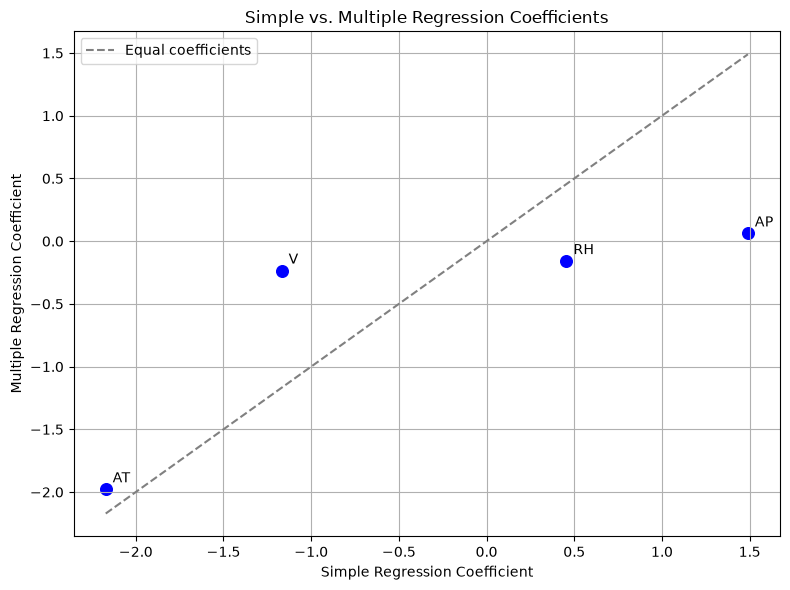

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    coefficient_comparison['Simple Regression'],
    coefficient_comparison['Multiple Regression'],
    color='blue',
    s=70
)

for predictor in predictors:
    x = coefficient_comparison.loc[
        predictor, 'Simple Regression'
    ]
    
    y = coefficient_comparison.loc[
        predictor, 'Multiple Regression'
    ]
    
    plt.annotate(
        predictor,
        (x, y),
        xytext=(5, 5),
        textcoords='offset points'
    )

# reference line showing where the coefficients would be equal
minimum = coefficient_comparison.min().min()
maximum = coefficient_comparison.max().max()

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--',
    color='gray',
    label='Equal coefficients'
)

plt.xlabel('Simple Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Simple vs. Multiple Regression Coefficients')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The AT coefficient is similar in both models. However, the magnitudes of the V and AP coefficients are much smaller in the multiple regression model. The RH coefficient changes from positive to negative.

These differences occur because simple regression considers each predictor separately, whereas multiple regression estimates each coefficient while controlling for the other predictors.

1f.

In [62]:
polynomial_models = {}
polynomial_results = []

for feature in predictors:
    polynomial_data = pd.DataFrame({'x': data[feature], 'x_squared': data[feature] ** 2, 'x_cubed': data[feature] ** 3})
    polynomial_data = sm.add_constant(polynomial_data, has_constant='add')

    model = sm.OLS(data['PE'], polynomial_data).fit()
    
    polynomial_models[feature] = model
    
    polynomial_results.append({
        'Predictor': feature,
        'Linear p-value': model.pvalues['x'],
        'Quadratic p-value': model.pvalues['x_squared'],
        'Cubic p-value': model.pvalues['x_cubed'],
        'R-squared': model.rsquared
    })

polynomial_table = pd.DataFrame(polynomial_results)
polynomial_table
polynomial_table.style.format({
    'Linear p-value': '{:.3e}',
    'Quadratic p-value': '{:.3e}',
    'Cubic p-value': '{:.3e}',
    'R-squared': '{:.4f}'
})

/var/folders/5s/c3_5hv6122j2yk63gq_jf36c0000gn/T/ipykernel_75300/1296308626.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data['PE'], polynomial_data).fit()


,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898e-07,8.833e-73,3.652e-110,0.9119
1,V,2.527e-05,7.685e-01,1.373e-02,0.7750
2,AP,4.503e-17,3.667e-17,8.264e-18,0.2749
3,RH,3.773e-04,9.395e-06,1.440e-05,0.1537


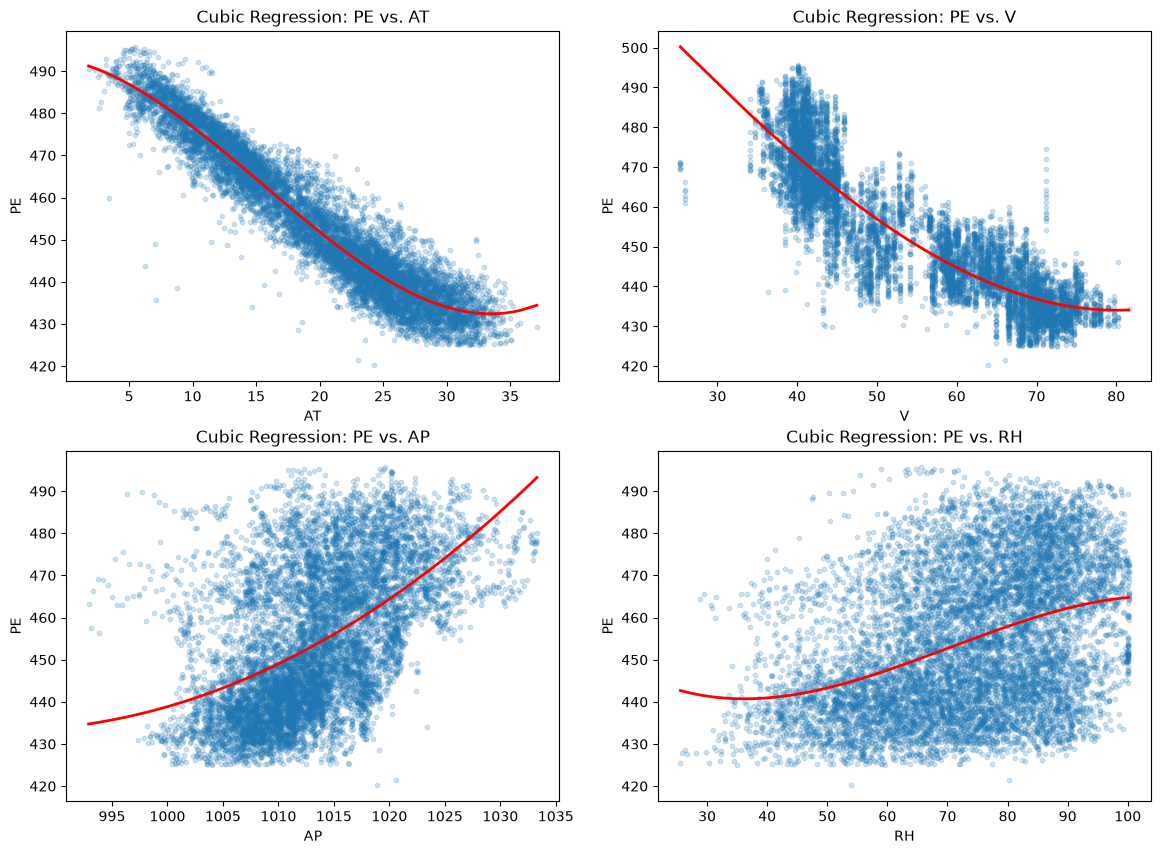

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, ax in zip(predictors, axes.flatten()):
    model = polynomial_models[feature]
    
    sorted_values = np.sort(data[feature])
    
    prediction_data = pd.DataFrame({'x': sorted_values, 'x_squared': sorted_values ** 2, 'x_cubed': sorted_values ** 3})
    prediction_data = sm.add_constant(prediction_data, has_constant='add')
    predictions = model.predict(prediction_data)
    
    ax.scatter(data[feature], data['PE'], alpha=0.2, s=10)
    
    ax.plot(sorted_values, predictions, color='red', linewidth=2)
    
    ax.set_title(f'Cubic Regression: PE vs. {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('PE')

plt.show()

There is evidence of a nonlinear association between every predictor and PE. For AT, AP, and RH, both the quadratic and cubic terms are statistically significant. For V, the quadratic term is not significant p=0.7685, but the cubic term is significant p=0.0137.

The nonlinear models improve R^2 most noticeably for AT and V, while the improvements for AP and RH are relatively small.

1g.

In [64]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(formula='PE ~ (AT + V + AP + RH) ** 2', data=data).fit()

print(interaction_model.summary())

interaction_terms = [
term for term in interaction_model.params.index
    if ':' in term
]

interaction_results = pd.DataFrame({'Coefficient': interaction_model.params[interaction_terms], 'p-value': interaction_model.pvalues[interaction_terms]})
interaction_results['Significant'] = (interaction_results['p-value'] < 0.05)
interaction_results

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:29:54   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,Coefficient,p-value,Significant
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


The interaction model has an R^2 of 0.936, compared with 0.929 for the model without interactions.

The significant interaction terms are AT:V, AT:RH, V:AP, and AP:RH p<0.05. AT:AP and V:RH are not statistically significant.
Therefore, there is evidence that some pairs of predictors interact in their association with PE.

1h.

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = data[['AT', 'V', 'AP', 'RH']]
y = data['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 6697
Testing observations: 2871


In [ ]:
#linear regression using all predictors:
import statsmodels.api as sm

X_train_linear = sm.add_constant(X_train)
X_test_linear = sm.add_constant(X_test)

linear_model = sm.OLS(y_train, X_train_linear).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:29:54   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        467.8414     11.502     40.673      0.0

In [67]:
#linear model errors:
linear_train_predictions = linear_model.predict(X_train_linear)
linear_test_predictions = linear_model.predict(X_test_linear)

linear_train_mse = mean_squared_error(y_train, linear_train_predictions)
linear_test_mse = mean_squared_error(y_test, linear_test_predictions)

print("Linear training MSE:", linear_train_mse)
print("Linear testing MSE:", linear_test_mse)

Linear training MSE: 20.580839725738695
Linear testing MSE: 21.239856938225444


In [68]:
#quadratic and interaction model
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

term_names = poly.get_feature_names_out(X.columns)

X_train_poly = pd.DataFrame(X_train_poly, columns=term_names, index=X_train.index)

X_test_poly = pd.DataFrame(X_test_poly, columns=term_names, index=X_test.index)

print(term_names)

X_train_poly_constant = sm.add_constant(X_train_poly)

full_poly_model = sm.OLS(y_train,X_train_poly_constant).fit()

print(full_poly_model.summary())

['AT' 'V' 'AP' 'RH' 'AT^2' 'AT V' 'AT AP' 'AT RH' 'V^2' 'V AP' 'V RH'
 'AP^2' 'AP RH' 'RH^2']
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:29:54   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [69]:
#remove insignificant terms:
remaining_terms = list(term_names)

def can_remove(term, terms):
    original_predictors = ['AT', 'V', 'AP', 'RH']

    if term not in original_predictors:
        return True

    for current_term in terms:
        if current_term == term:
            continue

        parts = current_term.replace('^2', '').split()

        if term in parts:
            return False

    return True

In [70]:
while True:
    X_current = sm.add_constant(
        X_train_poly[remaining_terms]
    )

    current_model = sm.OLS(y_train, X_current).fit()
    p_values = current_model.pvalues.drop('const')

    removable_terms = []

    for term in remaining_terms:
        if p_values[term] > 0.05:
            if can_remove(term, remaining_terms):
                removable_terms.append(term)

    if len(removable_terms) == 0:
        break

    worst_term = p_values[removable_terms].idxmax()
    remaining_terms.remove(worst_term)

    print("Removed:", worst_term)

Removed: V RH
Removed: V^2
Removed: V AP


In [71]:
#retained terms and final model:
print("Terms retained:")
print(remaining_terms)

X_train_reduced = sm.add_constant(X_train_poly[remaining_terms])

reduced_model = sm.OLS(y_train, X_train_reduced).fit()

print(reduced_model.summary())

Terms retained:
['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:29:55   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [72]:
#reduced errors:
X_test_reduced = sm.add_constant(X_test_poly[remaining_terms], has_constant='add')

reduced_train_predictions = reduced_model.predict( X_train_reduced)
reduced_test_predictions = reduced_model.predict(X_test_reduced)

reduced_train_mse = mean_squared_error( y_train, reduced_train_predictions)

reduced_test_mse = mean_squared_error(y_test, reduced_test_predictions)

print("Reduced model training MSE:", reduced_train_mse)
print("Reduced model testing MSE:", reduced_test_mse)

Reduced model training MSE: 17.89084277318489
Reduced model testing MSE: 18.66004049511268


In [73]:
mse_table = pd.DataFrame({
    'Model': [
        'Linear model',
        'Reduced quadratic and interaction model'
    ],
    'Training MSE': [
        linear_train_mse,
        reduced_train_mse
    ],
    'Testing MSE': [
        linear_test_mse,
        reduced_test_mse
    ]
})

mse_table.round(4)

,Model,Training MSE,Testing MSE
0,Linear model,20.5808,21.2399
1,Reduced quadratic and interaction model,17.8908,18.6600


The linear model has a training MSE of 20.5808 and a testing MSE of 21.2399. The reduced quadratic and interaction model has a lower training MSE of 17.8908 and a lower testing MSE of 18.6600.

Therefore, the reduced quadratic and interaction model performs better than the original linear model. Since both the training and testing errors decreased, there is no clear evidence that the improvement is only due to overfitting.

1i.

In [74]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_predictions = knn.predict(X_train)
    test_predictions = knn.predict(X_test)

    raw_train_mse.append(mean_squared_error(y_train, train_predictions))

    raw_test_mse.append(mean_squared_error(y_test, test_predictions))


best_raw_position = np.argmin(raw_test_mse)
best_raw_k = list(k_values)[best_raw_position]

print("Best k using raw features:", best_raw_k)
print("Raw training MSE:", raw_train_mse[best_raw_position])
print("Raw testing MSE:", raw_test_mse[best_raw_position])

Best k using raw features: 5
Raw training MSE: 10.600768887561596
Raw testing MSE: 15.726819842563568


In [75]:
scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_normalized, y_train)

    train_predictions = knn.predict(X_train_normalized)
    test_predictions = knn.predict(X_test_normalized)

    normalized_train_mse.append(mean_squared_error(y_train, train_predictions))

    normalized_test_mse.append(mean_squared_error(y_test, test_predictions))


best_normalized_position = np.argmin(normalized_test_mse)
best_normalized_k = list(k_values)[best_normalized_position]

print("Best k using normalized features:", best_normalized_k)
print("Normalized training MSE:", normalized_train_mse[best_normalized_position])
print("Normalized testing MSE:", normalized_test_mse[best_normalized_position])

Best k using normalized features: 4
Normalized training MSE: 8.591432839331045
Normalized testing MSE: 14.305669422675024


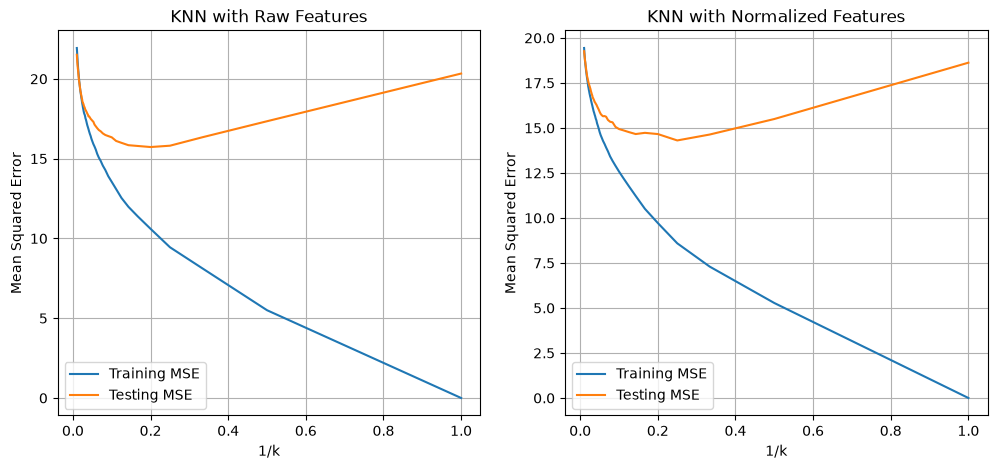

In [76]:
inverse_k = [1 / k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(inverse_k, raw_train_mse, label="Training MSE")
axes[0].plot(inverse_k, raw_test_mse, label="Testing MSE")
axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid()

axes[1].plot(inverse_k, normalized_train_mse, label="Training MSE")
axes[1].plot(inverse_k, normalized_test_mse, label="Testing MSE")
axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid()

plt.show()

For the raw features, the best value is k=5, with a test MSE of 15.7268. For the normalized features, the best value is \(k=4\), with a test MSE of 14.3057.

The normalized KNN model performs better because it has the lower test MSE. Normalization helps KNN because it prevents variables with larger scales from having too much influence on the distance calculation.

1j.

In [77]:
model_comparison = pd.DataFrame({
    'Model': ['Linear regression', 'Reduced quadratic and interaction regression', 'KNN with raw features', 'KNN with normalized features'],
    'Testing MSE': [linear_test_mse, reduced_test_mse, min(raw_test_mse), min(normalized_test_mse)]
})

model_comparison.round(4)

,Model,Testing MSE
0,Linear regression,21.2399
1,Reduced quadratic and interaction regression,18.6600
2,KNN with raw features,15.7268
3,KNN with normalized features,14.3057


The normalized KNN model has the lowest test MSE of 14.3057. The raw KNN model has a test MSE of 15.7268, while the reduced quadratic and interaction regression model has a test MSE of 18.6600.

Therefore, KNN regression performs better than the best linear regression model for this dataset. Normalized KNN gives the best overall test performance.

2.

a. A flexible method would generally perform better. Since the sample size is very large and the number of predictors is small, there is enough data to estimate a more complex relationship without serious overfitting.

b. A flexible method would generally perform worse. With many predictors but few observations, it is likely to overfit the training data and have high variance.

c. A flexible method would generally perform better. It can capture the highly nonlinear relationship between the predictors and the response, while an inflexible method may have high bias.

d. A flexible method would generally perform worse. When the error variance is very high, it may fit the noise in the training data, resulting in overfitting and poor performance on new data.

3.

In [78]:
df = pd.DataFrame({
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y':  ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
}, index=pd.Index([1, 2, 3, 4, 5, 6], name='Obs'))
#df

a. 

In [79]:
test_point = np.array([0, 0, 0])

df['distance'] = np.sqrt(((df[['X1', 'X2', 'X3']] - test_point) ** 2).sum(axis=1))
df_sorted = df.sort_values('distance')
df_sorted

,X1,X2,X3,Y,distance
Obs,,,,,
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051
2,2,0,0,Red,2.000000
4,0,1,2,Green,2.236068
1,0,3,0,Red,3.000000
3,0,1,3,Red,3.162278


b.

In [80]:
K = 1
neighbors_k1 = df_sorted.iloc[:K]
pred_k1 = neighbors_k1['Y'].mode()[0]

print(f"1 nearest neighbor :\n{neighbors_k1}\n")
print(f"Prediction with K=1: {pred_k1}")

1 nearest neighbor :
     X1  X2  X3      Y  distance
Obs                             
5    -1   0   1  Green  1.414214

Prediction with K=1: Green


c. 

In [81]:
K = 3
neighbors_k3 = df_sorted.iloc[:K]
pred_k3 = neighbors_k3['Y'].mode()[0]

print(f"3 nearest neighbors:\n{neighbors_k3}\n")
print(f"Prediction with K=3 : {pred_k3}")

3 nearest neighbors:
     X1  X2  X3      Y  distance
Obs                             
5    -1   0   1  Green  1.414214
6     1   1   1    Red  1.732051
2     2   0   0    Red  2.000000

Prediction with K=3 : Red


d.

If the Bayes decision boundary is highly nonlinear, we'd want a SMALL K. Small K means more flexible, low bias/high variance classifier that can trace a complex, wiggly boundary.

Large K averages over more neighbors, producing a smoother (closer to linear) boundary, which would underfit a highly nonlinear true boundary.